# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [2]:
proteins_df = pg.merge_resources(rows_per_id=None)
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:07<00:00,  3.79s/it]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
0,NP_005680.1,NP_005680,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_005680.1,ABCB6,ENSG00000115657,ENST00000265316,ENSP00000265316
1,NP_057664.1,NP_057664,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_057664.1,PCDH12,ENSG00000113555,ENST00000231484,ENSP00000231484
2,NP_001356.1,NP_001356,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001356.1,DLG4,ENSG00000132535,ENST00000648172,ENSP00000497806
3,NP_001877.1,NP_001877,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001877.1,CRYBA4,ENSG00000196431,ENST00000354760,ENSP00000346805
4,NP_001783.2,NP_001783,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001783.2,CDH2,ENSG00000170558,ENST00000269141,ENSP00000269141
...,...,...,...,...,...,...,...,...,...
4774,NP_001242976.1,NP_001242976,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001242976.1,C19orf12,ENSG00000131943,ENST00000614091,ENSP00000482097
4775,NP_001367.2,NP_001367,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001367.2,NaN,NaN,NaN,NaN
4776,NP_054728.2,NP_054728,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_054728.2,FOXP3,ENSG00000049768,ENST00000376207,ENSP00000365380
4777,NP_001125.1,NP_001125,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001125.1,AFP,ENSG00000081051,ENST00000395792,ENSP00000379138


In [3]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins['protein'] = candidate_proteins['RefSeq Protein']
# candidate_proteins = er.map_ids(df=candidate_proteins,
#                                 input_col="RefSeq Protein")
candidate_proteins = pg.map_resources(df=candidate_proteins)
candidate_proteins

Mapping Proteingym IDs
Loading mapping file from /grid/koo/home/schilder/.cache/ProteinGym/proteingym_id_map_693de35055033c431bc1452512841718.csv.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,RefSeq Protein Stable,protein,genename,ENSG,ENST,ENSP
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,NP_001346945.1,NaN,NaN,NaN,NaN
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,NP_000401,NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,NP_000483,NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283
4,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000352993,ENSP00000312236
5,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,NP_000050,NP_000050.3,NaN,NaN,NaN,NaN
6,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,NP_000121,NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771
7,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,NP_000509,NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994
8,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,NP_000286,NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299
9,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,NP_000518,NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [ ]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(tx_ids=candidate_proteins["ENST"],
                              #  use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Getting haplotypes:   0%|          | 0/10 [00:00<?, ?it/s]

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [ ]:
prot_df = vp.filter_prot_df(proteins_df,
                            protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 11 protein ids
Filtering by 1 source types
Filtering by ENST haplotypes


Getting haplotype sequences:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Returning 6 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,Feature,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
2092,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,NM_000518.5,HBB;HBB,ENSG00000244734,ENST00000335295,ENSP00000333994,[147],[147],1.0,True
2093,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,NM_000518.5,HBB;HBB;HBB,ENSG00000244734,ENST00000335295,ENSP00000333994,[147],[147],1.0,True
2094,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,NM_000518.5,HBB;HBB;HBB;HBB,ENSG00000244734,ENST00000335295,ENSP00000333994,[147],[147],1.0,True
3153,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,NM_000410.4,HFE;HFE;HFE;HFE;HFE;HFE;HFE,ENSG00000010704,ENST00000357618,ENSP00000417404,[348],[348],1.0,True
3154,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,NM_000410.4,HFE;HFE;HFE;HFE;HFE;HFE;HFE;HFE;HFE;HFE,ENSG00000010704,ENST00000357618,ENSP00000417404,[348],[348],1.0,True
3368,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,NM_007294.4,BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True
3369,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,NM_007294.4,BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA...,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True
3370,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,NM_007294.4,BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA...,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True
3371,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,NM_007294.4,BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA1;BRCA...,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True
3372,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,NM_007294.4,BRCA1;BRCA1;BRCA1;BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283,[1863],[1863],1.0,True


We also need to remove any suspcious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [7]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
48,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSG00000012048,ENSP00000350283,ENST00000357654,[1863],[1863],1.0,True
143,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENSG00000001626,ENSP00000003084,ENST00000003084,[1480],[1480],1.0,True
1173,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSG00000055118,ENSP00000262186,ENST00000262186,[1159],[1159],1.0,True
1611,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSG00000010704,ENSP00000417404,ENST00000357618,[348],[348],1.0,True
1786,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSG00000244734,ENSP00000333994,ENST00000335295,[147],[147],1.0,True
3334,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSG00000130164,ENSP00000454071,ENST00000558518,[860],[860],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [7]:
vp.list_models(as_list=False)

Available models:
- esm1_t12_85M_UR50S
- esm1_t34_670M_UR100
- esm1_t34_670M_UR50D
- esm1_t34_670M_UR50S
- esm1_t6_43M_UR50S
- esm1b_t33_650M_UR50S
- esm1v_t33_650M_UR90S
- esm1v_t33_650M_UR90S_1
- esm1v_t33_650M_UR90S_2
- esm1v_t33_650M_UR90S_3
- esm1v_t33_650M_UR90S_4
- esm1v_t33_650M_UR90S_5
- esm2
- esm2_t12_35M_UR50D
- esm2_t30_150M_UR50D
- esm2_t33_650M_UR50D
- esm2_t36_3B_UR50D
- esm2_t48_15B_UR50D
- esm2_t6_8M_UR50D
- esm_if1_gvp4_t16_142M_UR50
- esm_msa1_t12_100M_UR50S
- esm_msa1b_t12_100M_UR50S
- esmfold_structure_module_only_150M
- esmfold_structure_module_only_150M_270K
- esmfold_structure_module_only_15B
- esmfold_structure_module_only_35M
- esmfold_structure_module_only_35M_270K
- esmfold_structure_module_only_3B
- esmfold_structure_module_only_3B_270K
- esmfold_structure_module_only_650M
- esmfold_structure_module_only_650M_270K
- esmfold_structure_module_only_8M
- esmfold_structure_module_only_8M_270K
- esmfold_v0
- esmfold_v1


Run VEP pipeline and store the results in `save_dir`.

In [9]:
save_dir = os.path.join(config.DATA_DIR,"1KG","vep")

In [ ]:
save_paths = vp.vep_pipeline(
    prot_df = prot_df,
    haplotypes = haplotypes,
    save_dir = save_dir,
    models = [
        "esm1_t6_43M_UR50S",
          "esm1_t34_670M_UR50D",
          "esm1v_t33_650M_UR90S_1",
          "esm1b_t33_650M_UR50S",
          "esm2_t12_35M_UR50D",
          "esm2_t33_650M_UR50D",
          "esm2_t48_15B_UR50D",
#           "esmfold_v1"
             ],
    scoring_strategies = [
        "wt-marginals", 
        "masked-marginals",
        # "pseudo-ppl" # Takes much longer to run
        ],
    source_types = ["clinical_ProteinGym_substitutions"],
#     verbose = False
    )
save_paths

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

### Merge VEP results files

In [8]:
vep_df = va.merge_vep(add_metadata=True)
vep_df

No save_dir provided, using: /grid/koo/home/schilder/projects/data/1KG/vep
Found 1696 wt-marginals files


Reading files: 100%|██████████| 1696/1696 [01:04<00:00, 26.11it/s]


Found 1696 masked-marginals files


Reading files: 100%|██████████| 1696/1696 [01:03<00:00, 26.87it/s]


Found 0 pseudo-ppl files


Gathering resources: 100%|██████████| 2/2 [00:00<00:00,  3.44it/s]
/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3301: DtypeWarning: Columns (0,47) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,...,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-0.428001,wt-marginals,False,esm1_t6_43M_UR50S,...,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.537646,wt-marginals,False,esm1_t6_43M_UR50S,...,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
2,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.259839,wt-marginals,False,esm1_t6_43M_UR50S,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.943518,-0.011925,7,likely_path
3,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-0.480459,wt-marginals,False,esm1_t6_43M_UR50S,...,ClinGen:CA16602290,NaN,NaN,NaN,NaN,NaN,-0.349066,-0.000457,7,likely_benign
4,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-2.359585,wt-marginals,False,esm1_t6_43M_UR50S,...,"ClinGen:CA023728|LDLR-LOVD,_British_Heart_Foun...",NaN,NaN,NaN,NaN,NaN,-0.693519,-0.002438,7,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102123,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.801524,masked-marginals,False,esm2_t33_650M_UR50D,...,ClinGen:CA10602052,NaN,NaN,NaN,NaN,NaN,-4.274609,NaN,6,likely_path
1102124,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.397738,masked-marginals,False,esm2_t33_650M_UR50D,...,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,NaN,NaN,NaN,NaN,NaN,-0.984293,NaN,6,path
1102125,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.547280,masked-marginals,False,esm2_t33_650M_UR50D,...,ClinGen:CA003549,NaN,NaN,NaN,NaN,NaN,-3.694999,NaN,6,likely_path
1102126,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,R7L,MDLSALLVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-0.879945,masked-marginals,False,esm2_t33_650M_UR50D,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.126186,NaN,5,likely_benign


In [9]:
# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes)

# Check if any haplotypes with variants that are out of frame
print(vep_df.loc[vep_df['mutant_out_of_frame']==True]['haplotype'].unique())

# Filter out variants that are out of frame, as they should not not be able to produce a VEP
# vep_df = vep_df.loc[vep_df['mutant_out_of_frame']==False]

Adding 'haplotype_sequence' column
Found 557 haplotypes in: '/grid/koo/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/557 [00:00<?, ?it/s]

Getting haplotype sequences


Getting haplotype sequences:   0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Adding 'haplotype_sequence_len' column
Adding 'mutant_out_of_frame' column
[]


In [19]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [20]:
seq_check_df, clinsig_counts, mutant_in_haplotype = va.report_vep(vep_df)
display(seq_check_df, clinsig_counts, mutant_in_haplotype)

,clinsig,mismatched_length,identical_sequences
0,benign,0,0
1,likely_benign,0,0
2,likely_path,0,0
3,path,0,0


,clinsig_count
clinsig,
likely_path,297545
path,85977
likely_benign,72289
benign,40869


,mutant_in_haplotype,clinsig,variant_count,variant_count_by_clinsig,variant_proportion,haplotype_count,haplotype_count_by_clinsig,haplotype_proportion
0,False,benign,146,199,0.733668,209,319,0.655172
1,False,likely_benign,248,263,0.942966,379,480,0.789583
2,False,likely_path,797,801,0.995006,360,365,0.986301
3,False,path,315,327,0.963303,379,392,0.966837
4,True,benign,53,199,0.266332,110,319,0.344828
5,True,likely_benign,15,263,0.057034,101,480,0.210417
6,True,likely_path,4,801,0.004994,5,365,0.013699
7,True,path,12,327,0.036697,13,392,0.033163


## Plots: All Proteins

### Density plots

Filtered 0.7% of rows with NAs in col 'VEP'


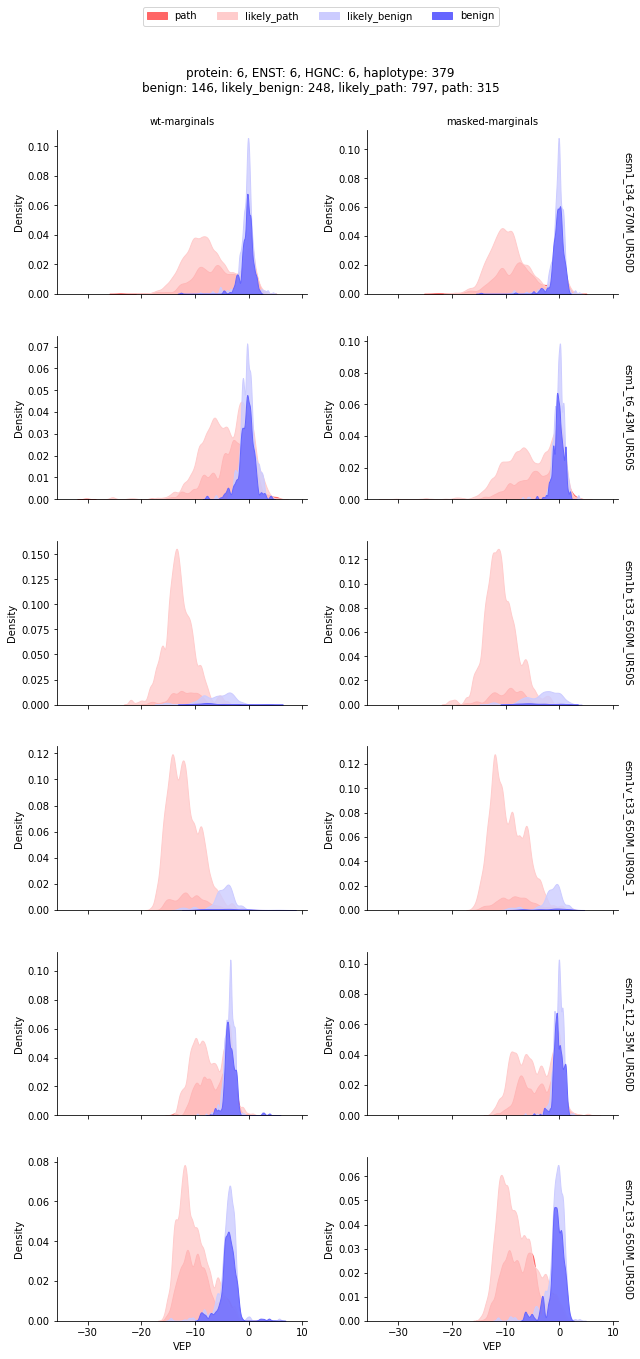

In [10]:
va.plot_vep_density(vep_df, 
                     multiple=['layer','stack','fill'][0]
                     )

### Variance plots

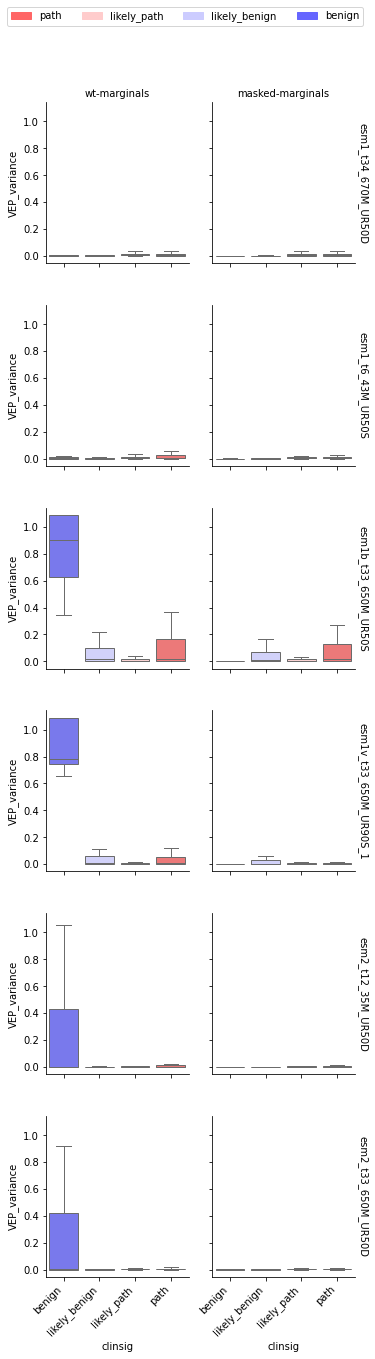

In [11]:
vep_variance = va.plot_vep_variance(vep_df, 
                                    return_df=True,
                                    showfliers=False,
                                    groupby_cols = ['model_location','protein',
                                                    'clinsig','mutant','scoring_strategy']
                                                    )

### Benign/Pathogenic Ratio

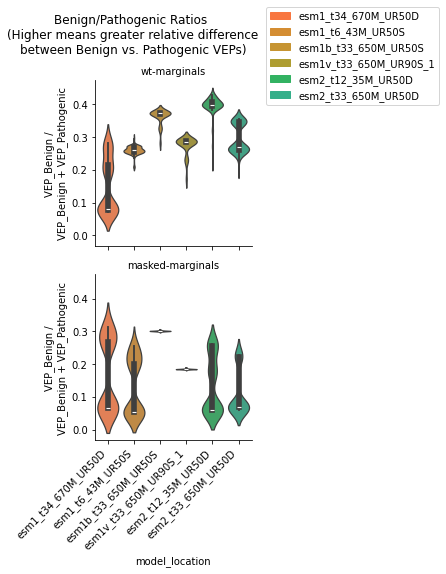

In [12]:
vep_pbratios = va.plot_vep_bpratios(vep_df,
                                     y=['benign_path_ratio','benign_path_ratio_strict'][1]
                                     )

## Plots: Single Protein

### Violin plots: wt-marginals

Filtered 0.0% of rows with NAs in col 'VEP'


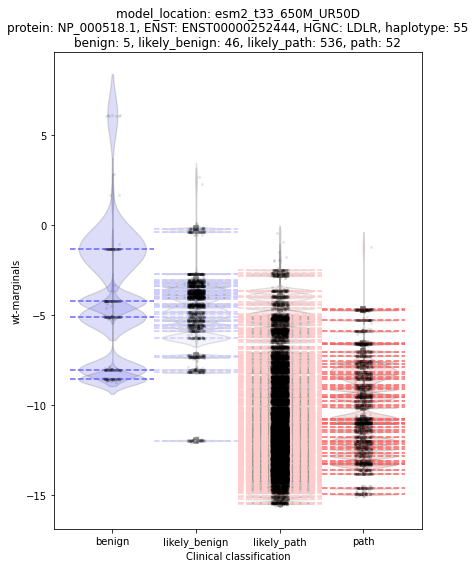

In [13]:
va.plot_vep_violin(vep_df, 
                   model_location="esm2_t33_650M_UR50D",
                   max_proteins=1,
                   max_models=1,
                   scoring_strategy="wt-marginals")

### Violin plots: masked-marginals

Filtered 0.0% of rows with NAs in col 'VEP'


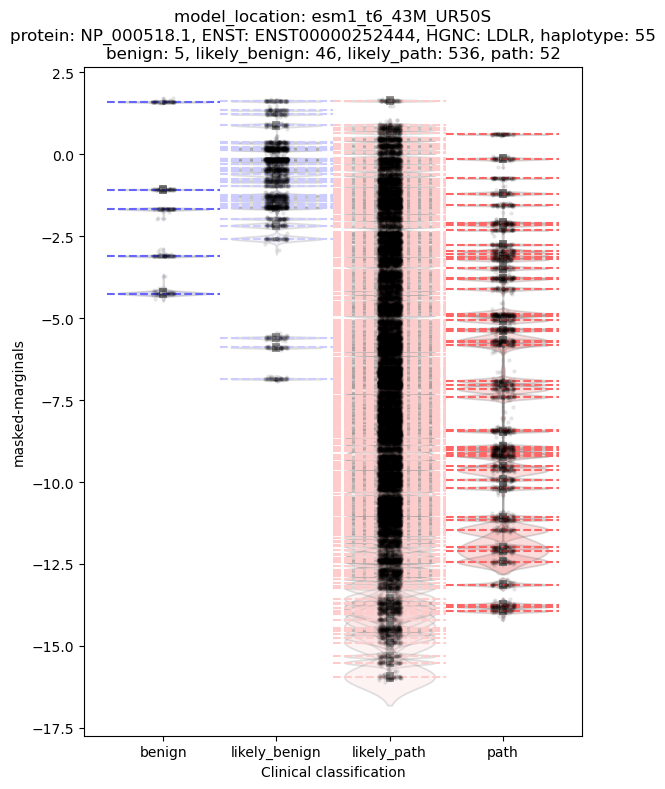

In [42]:
va.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    max_models=1,
                    scoring_strategy="masked-marginals")

### Haplotype Representiveness

In [15]:
vep_df['VEP_percentile'] = vep_df.groupby(['model_location', 'protein', 'mutant','scoring_strategy'])['VEP'].rank(pct=True)
vep_df[['VEP_percentile']]

,VEP_percentile
0,0.218182
1,0.527273
2,0.272727
3,0.427273
4,0.400000
...,...
1102123,0.777778
1102124,0.851852
1102125,0.907407
1102126,0.064220


### Reference Representativeness: Percentiles

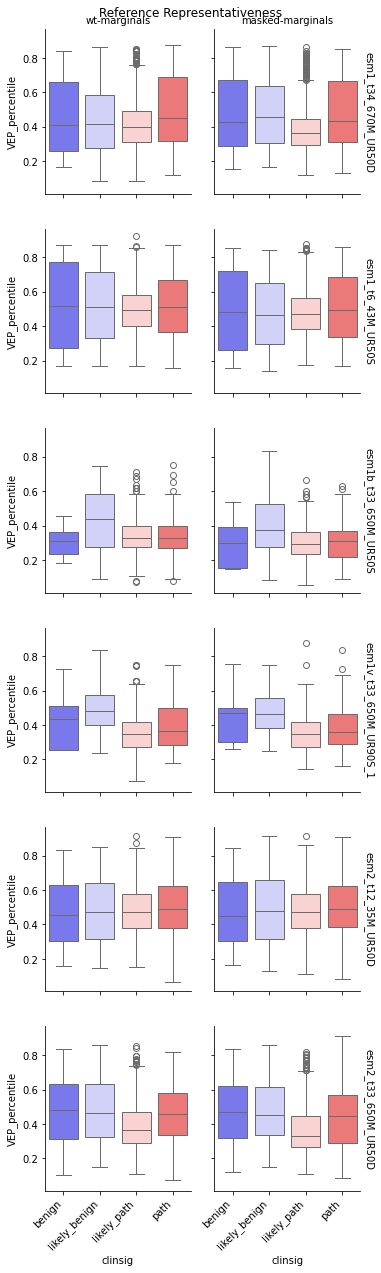

In [16]:
va.plot_vep_percentiles(vep_df)

In [17]:
vep_df.loc[vep_df['is_ref']==True]['VEP_percentile'].describe()

count    14876.000000
mean         0.438028
std          0.167548
min          0.054545
25%          0.309091
50%          0.418182
75%          0.545455
max          0.923077
Name: VEP_percentile, dtype: float64